In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


# Original dataset:

In [2]:
df_train = pd.read_csv(r'../dataset/UNSW/preprocessed/UNSW_trainING_preprocessed.csv')
df_test = pd.read_csv(r'../dataset/UNSW/preprocessed/UNSW_testING_preprocessed.csv')

y_train = df_train['attack_cat']
X_train = df_train.drop(labels= 'attack_cat', axis= 1).copy()

y_test = df_test['attack_cat']
X_test = df_test.drop(labels= 'attack_cat', axis= 1).copy()

In [3]:
all_classes = np.union1d(np.unique(y_train), np.unique(y_test))
N_CLASSES   = len(all_classes)
N_FEATURES  = X_train.shape[1]

LABEL_NAME_MAP = {'Analysis': 0, 'Backdoor': 1, 'DoS': 2, 'Exploits': 3, 'Fuzzers': 4, 'Generic': 5, 'Normal': 6, 'Reconnaissance': 7, 'Shellcode': 8, 'Worms': 9}

CLASS_NAMES = [LABEL_NAME_MAP.get(i, f'Class_{i}') for i in all_classes]

In [4]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

def evaluate(name, y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1_mac = f1_score(
        y_true,
        y_pred,
        average='macro'
    )

    print(f'\n=== {name} ===')

    print(
        f'Accuracy : {acc:.4f} | '
        f'Precision : {precision:.4f} | '
        f'Recall : {recall:.4f} | '
        f'Weighted F1 : {f1:.4f} | '
        f'Macro F1 : {f1_mac:.4f}'
    )

    print(
        classification_report(
            y_true,
            y_pred,
            labels=all_classes,
            target_names=CLASS_NAMES
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=all_classes
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax
    )

    ax.set_title(f'{name} — Confusion Matrix')

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    plt.tight_layout()

    plt.show()

    return acc, precision, recall, f1, f1_mac


RESULTS = {}

## Random forest:

Best params: {'criterion': 'gini', 'max_depth': 25, 'n_estimators': 43}
Best params: {'criterion': 'gini', 'max_depth': 25, 'n_estimators': 43}

=== Random Forest ===
Accuracy : 0.7480 | Precision : 0.8430 | Recall : 0.7480 | Weighted F1 : 0.7745 | Macro F1 : 0.4942
              precision    recall  f1-score   support

     Class_0       0.06      0.07      0.06       446
     Class_1       0.10      0.30      0.15       346
     Class_2       0.70      0.18      0.29      1718
     Class_3       0.71      0.87      0.78      7609
     Class_4       0.29      0.68      0.41      4838
     Class_5       1.00      0.84      0.91      3657
     Class_6       0.97      0.76      0.85     34206
     Class_7       0.85      0.77      0.81      2703
     Class_8       0.39      0.70      0.50       378
     Class_9       0.62      0.11      0.19        44

    accuracy                           0.75     55945
   macro avg       0.57      0.53      0.49     55945
weighted avg       0.84      

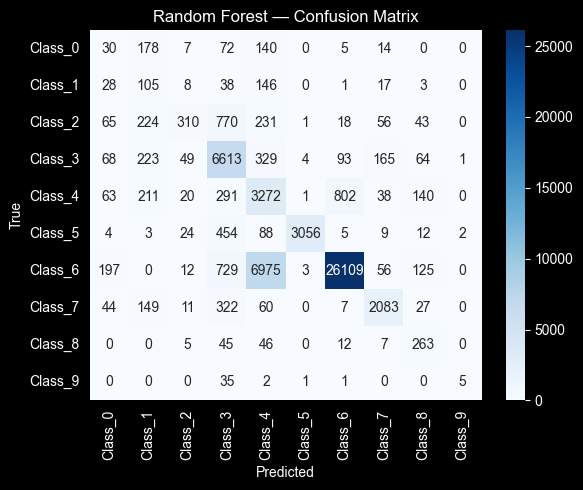

ValueError: too many values to unpack (expected 3)

In [12]:
model_rf = RandomForestClassifier(
    random_state= 42
)

random_forest = GridSearchCV(
    estimator= model_rf,
    param_grid= {
        "n_estimators" : [41, 42, 43],
        "criterion" : ['entropy', 'gini', 'log_loss'],
        "max_depth": [25],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

random_forest.fit(X_train, y_train)
print(f'Best params: {random_forest.best_params_}')

y_pred = random_forest.predict(X_test)
print(f'Best params: {random_forest.best_params_}')

label  = f"Random Forest"
acc, f1, macro = evaluate(label, y_test, y_pred)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

Best params: {'C': 10, 'kernel': 'linear', 'tol': 0.01}
Best params: {'C': 10, 'kernel': 'linear', 'tol': 0.01}

=== SVC ===
Accuracy : 0.6358 | Precision : 0.8018 | Recall : 0.6358 | Weighted F1 : 0.6713 | Macro F1 : 0.3415
              precision    recall  f1-score   support

     Class_0       0.11      0.27      0.16       446
     Class_1       0.08      0.03      0.05       346
     Class_2       0.37      0.01      0.02      1718
     Class_3       0.65      0.74      0.69      7609
     Class_4       0.24      0.85      0.37      4838
     Class_5       0.98      0.82      0.89      3657
     Class_6       0.98      0.62      0.76     34206
     Class_7       0.40      0.61      0.48      2703
     Class_8       0.00      0.00      0.00       378
     Class_9       0.00      0.00      0.00        44

    accuracy                           0.64     55945
   macro avg       0.38      0.40      0.34     55945
weighted avg       0.80      0.64      0.67     55945



C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\MSI\miniconda3\envs\tf\lib\site-packag

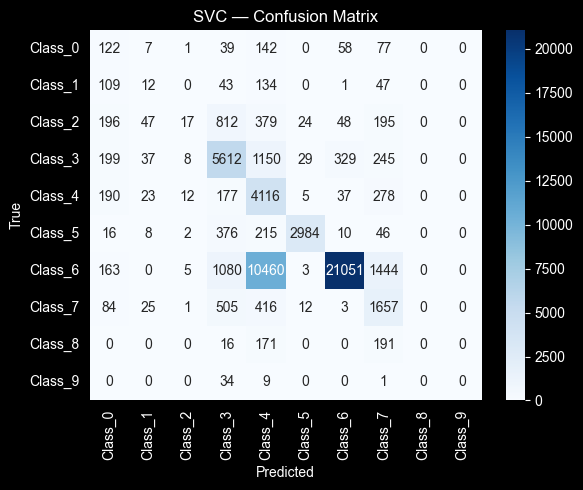

ValueError: too many values to unpack (expected 3)

In [13]:
model_svc = SVC(
    cache_size=1000
)

svc = GridSearchCV(
    estimator= model_svc,
    param_grid=  {
        'C': [5,10],
        'kernel': ['linear'],
        'tol': [1e-2]
    },
    cv= 3,
    scoring= 'f1_macro',
    n_jobs= -1
)

svc.fit(X_train, y_train)
print(f'Best params: {svc.best_params_}')

y_pred = svc.predict(X_test)
print(f'Best params: {svc.best_params_}')

label  = f"SVC"
acc, f1, macro = evaluate(label, y_test, y_pred)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
3 fits failed out of a total of 54.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
  File "C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\xgboost\sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "C:\Users\MSI\min

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 35, 'subsample': 0.8}

=== XGBoost ===
Accuracy : 0.7488 | Precision : 0.8484 | Recall : 0.7488 | Weighted F1 : 0.7773 | Macro F1 : 0.5366
              precision    recall  f1-score   support

     Class_0       0.10      0.21      0.14       446
     Class_1       0.11      0.30      0.16       346
     Class_2       0.58      0.21      0.31      1718
     Class_3       0.71      0.88      0.78      7609
     Class_4       0.30      0.71      0.42      4838
     Class_5       0.99      0.86      0.92      3657
     Class_6       0.98      0.75      0.85     34206
     Class_7       0.89      0.78      0.83      2703
     Class_8       0.40      0.76      0.53       378
     Class_9       0.72      0.30      0.42        44

    accuracy                           0.75     55945
   macro avg       0.58      0.58      0.54     55945
weighted avg       0.85      0.75      0

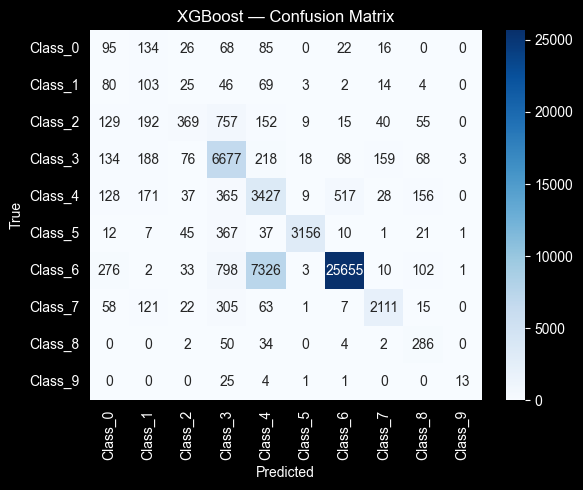

ValueError: too many values to unpack (expected 3)

In [14]:
from xgboost import XGBClassifier

model_xgboost = XGBClassifier(
    tree_method='hist',
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1,
    random_state=42
)
xgboost = GridSearchCV(
    estimator=model_xgboost,
    param_grid={
        'n_estimators': [30, 33, 35],
        'max_depth': [8, 9, 10],
        'learning_rate': [0.1, 0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [3]
    },
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

xgboost.fit(X_train, y_train)
print(f'Best params: {xgboost.best_params_}')
y_pred = xgboost.predict(X_test)
label = f"XGBoost"
acc, f1, macro = evaluate(label, y_test, y_pred)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

# filtering models

## Chi2

In [3]:
df_train_chi2 = pd.read_csv(r'../dataset/UNSW/filtered/UNSW_train_chi2.csv')
df_test_chi2 = pd.read_csv(r'../dataset/UNSW/filtered/UNSW_test_chi2.csv')

y_train_chi2 = df_train_chi2['attack_cat']
X_train_chi2 = df_train_chi2.drop(labels= ['attack_cat'], axis= 1).copy()

y_test_chi2 = df_test_chi2['attack_cat']
X_test_chi2 = df_test_chi2.drop(labels= ['attack_cat'], axis= 1).copy()

Best params: {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 110}
Best params: {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 110}

=== Random forest on Chi2110) ===
Accuracy : 0.6880 | Precision : 0.7964 | Recall : 0.6880 | Weighted F1 : 0.7208 | Macro F1 : 0.3891
              precision    recall  f1-score   support

     Class_0       0.08      0.10      0.09       446
     Class_1       0.08      0.26      0.13       346
     Class_2       0.41      0.10      0.16      1718
     Class_3       0.64      0.84      0.72      7609
     Class_4       0.21      0.46      0.29      4838
     Class_5       0.99      0.82      0.90      3657
     Class_6       0.97      0.73      0.83     34206
     Class_7       0.39      0.61      0.48      2703
     Class_8       0.17      0.20      0.18       378
     Class_9       0.38      0.07      0.12        44

    accuracy                           0.69     55945
   macro avg       0.43      0.42      0.39     55945
weighted avg   

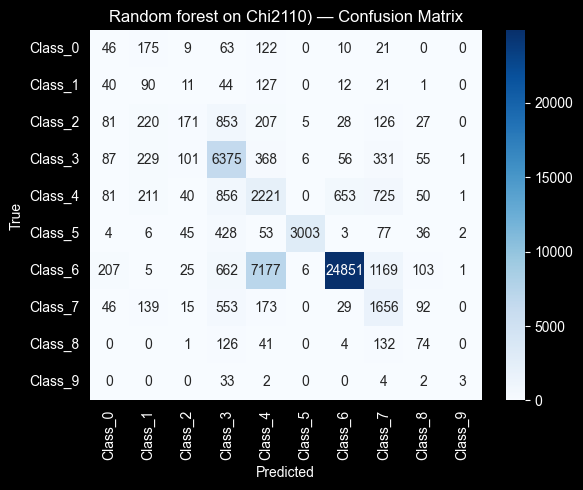

ValueError: too many values to unpack (expected 3)

In [27]:
model_rf = RandomForestClassifier(
    random_state= 42
)

random_forest_chi2 = GridSearchCV(
    estimator= model_rf,
    param_grid= {
        "n_estimators" : [100, 110],
        "criterion" : ['gini'],
        "max_depth": [20, 15],
    },
    cv= 5,
    scoring= 'f1_macro',
    n_jobs= -1
)

random_forest_chi2.fit(X_train_chi2, y_train_chi2)
print(f'Best params: {random_forest_chi2.best_params_}')

y_pred_chi2 = random_forest_chi2.predict(X_test_chi2)
print(f'Best params: {random_forest_chi2.best_params_}')

label  = f"Random forest on Chi2{random_forest_chi2.best_params_['n_estimators']})"
acc, f1, macro = evaluate(label, y_test_chi2, y_pred_chi2)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

In [ ]:
model_svc = SVC(
    cache_size=1000
)

svc_chi2 = GridSearchCV(
    estimator=model_svc,

    param_grid={
        'C': [5, 10],

        'kernel': ['linear'],

        'tol': [1e-2],
    },

    cv=3,

    scoring='f1_macro',

    n_jobs=-1
)

svc_chi2.fit(X_train_chi2, y_train_chi2)
print(f'Best params: {svc_chi2.best_params_}')

y_pred_chi2 = svc_chi2.predict(X_test_chi2)
print(f'Best params: {svc_chi2.best_params_}')

label  = f"SVC in Chi2"
acc, f1, macro = evaluate(label, y_test_chi2, y_pred_chi2)
RESULTS[label] = {'Accuracy': acc, 'F1': f1, 'Macro F1': macro}

Best params: {'learning_rate': 0.1, 'max_depth': 15, 'n_estimators': 110}
Best params: {'learning_rate': 0.1, 'max_depth': 15, 'n_estimators': 110}

=== XGBoost in Chi2 ===
Accuracy : 0.6970 | Precision : 0.7958 | Recall : 0.6970 | Weighted F1 : 0.7294 | Macro F1 : 0.3979
              precision    recall  f1-score   support

     Class_0       0.11      0.21      0.15       446
     Class_1       0.08      0.30      0.13       346
     Class_2       0.34      0.12      0.18      1718
     Class_3       0.65      0.83      0.73      7609
     Class_4       0.22      0.45      0.30      4838
     Class_5       0.99      0.81      0.89      3657
     Class_6       0.96      0.74      0.84     34206
     Class_7       0.44      0.63      0.52      2703
     Class_8       0.13      0.23      0.17       378
     Class_9       0.50      0.05      0.08        44

    accuracy                           0.70     55945
   macro avg       0.44      0.44      0.40     55945
weighted avg       0.80

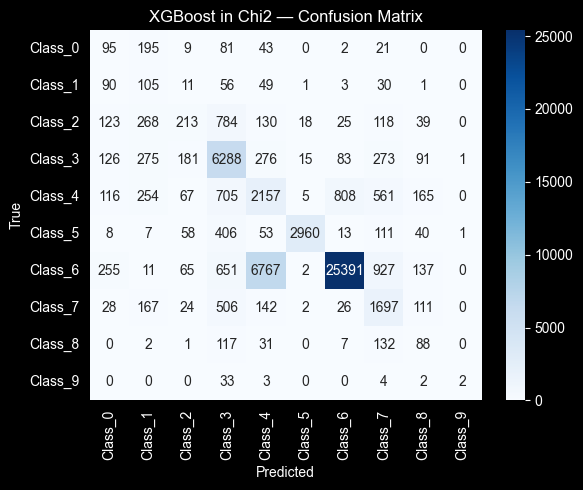

ValueError: too many values to unpack (expected 3)

In [21]:
model_xgboost = XGBClassifier(
    tree_method='hist',
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1,
    random_state=42
)

xgboost_chi2 = GridSearchCV(
    estimator=model_xgboost,
    param_grid={
        'n_estimators': [110, 115],
        'max_depth': [13, 15, 18],
        'learning_rate': [0.01, 0.1],
    },
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

xgboost_chi2.fit(
    X_train_chi2,
    y_train_chi2
)

print(f'Best params: {xgboost_chi2.best_params_}')

y_pred_chi2 = xgboost_chi2.predict(
    X_test_chi2
)

print(f'Best params: {xgboost_chi2.best_params_}')

label = f"XGBoost in Chi2"

acc, f1, macro = evaluate(
    label,
    y_test_chi2,
    y_pred_chi2
)

RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

## Mutual info models

In [4]:
df_train_mi = pd.read_csv(r'../dataset/UNSW/filtered/UNSW_train_mi.csv')
df_test_mi = pd.read_csv(r'../dataset/UNSW/filtered/UNSW_test_mi.csv')

y_train_mi = df_train_mi['attack_cat']
X_train_mi = df_train_mi.drop(labels= ['attack_cat'], axis= 1).copy()

y_test_mi = df_test_mi['attack_cat']
X_test_mi = df_test_mi.drop(labels= ['attack_cat'], axis= 1).copy()

In [5]:
model_rf = RandomForestClassifier(
    random_state=42
)
random_forest_mi = GridSearchCV(
    estimator=model_rf,
    param_grid={
       "n_estimators" : [100, 110],
        "criterion" : ['entropy', 'gini', 'log_loss'],
        "max_depth": [20, 15],
    },
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

random_forest_mi.fit(
    X_train_mi,
    y_train_mi
)
print(f'Best params: {random_forest_mi.best_params_}')
y_pred_mi = random_forest_mi.predict(
    X_test_mi
)
print(f'Best params: {random_forest_mi.best_params_}')
label = f"Random forest on MI ({random_forest_mi.best_params_['n_estimators']})"


Best params: {'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 110}
Best params: {'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 110}


NameError: name 'evaluate' is not defined


=== Random forest on MI (110) ===
Accuracy : 0.7549 | Precision : 0.8269 | Recall : 0.7549 | Weighted F1 : 0.7725 | Macro F1 : 0.4955
              precision    recall  f1-score   support

     Class_0       0.06      0.02      0.03       446
     Class_1       0.46      0.12      0.19       346
     Class_2       0.74      0.24      0.36      1718
     Class_3       0.73      0.84      0.78      7609
     Class_4       0.30      0.66      0.42      4838
     Class_5       0.99      0.86      0.92      3657
     Class_6       0.95      0.78      0.86     34206
     Class_7       0.52      0.85      0.64      2703
     Class_8       0.34      0.31      0.33       378
     Class_9       0.56      0.34      0.42        44

    accuracy                           0.75     55945
   macro avg       0.57      0.50      0.50     55945
weighted avg       0.83      0.75      0.77     55945



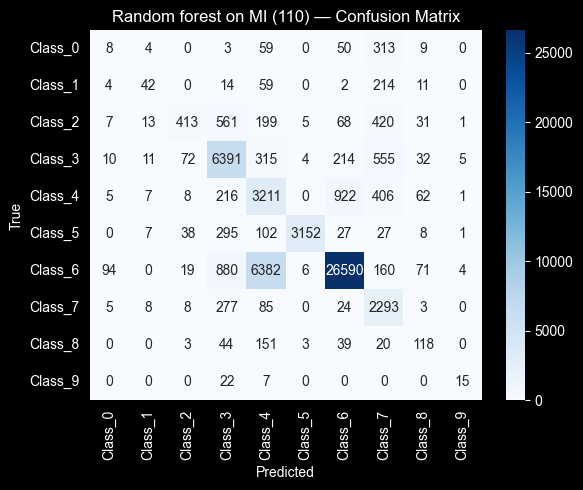

ValueError: too many values to unpack (expected 3)

In [13]:
acc, f1, macro = evaluate(
    label,
    y_test_mi,
    y_pred_mi
)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

In [ ]:
model_svc = SVC()

svc_mi = GridSearchCV(
    estimator=model_svc,
    param_grid={
        'C': [5, 10],
        'kernel': ['linear'],
        'gamma': ['scale'],
        'tol': [1e-3],
    },
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
svc_mi.fit(
    X_train_mi,
    y_train_mi
)
print(f'Best params: {svc_mi.best_params_}')
y_pred_mi = svc_mi.predict(
    X_test_mi
)
print(f'Best params: {svc_mi.best_params_}')
label = f"SVC in MI"
acc, f1, macro = evaluate(
    label,
    y_test_mi,
    y_pred_mi
)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

Best params: {'learning_rate': 0.15, 'max_depth': 8, 'n_estimators': 50}
Best params: {'learning_rate': 0.15, 'max_depth': 8, 'n_estimators': 50}

=== XGBoost in MI ===
Accuracy : 0.7569 | Precision : 0.8381 | Recall : 0.7569 | Weighted F1 : 0.7791 | Macro F1 : 0.5401
              precision    recall  f1-score   support

     Class_0       0.15      0.41      0.22       446
     Class_1       0.56      0.12      0.20       346
     Class_2       0.68      0.20      0.31      1718
     Class_3       0.73      0.83      0.78      7609
     Class_4       0.30      0.70      0.42      4838
     Class_5       0.99      0.86      0.92      3657
     Class_6       0.96      0.78      0.86     34206
     Class_7       0.74      0.79      0.76      2703
     Class_8       0.38      0.29      0.33       378
     Class_9       0.64      0.57      0.60        44

    accuracy                           0.76     55945
   macro avg       0.61      0.55      0.54     55945
weighted avg       0.84    

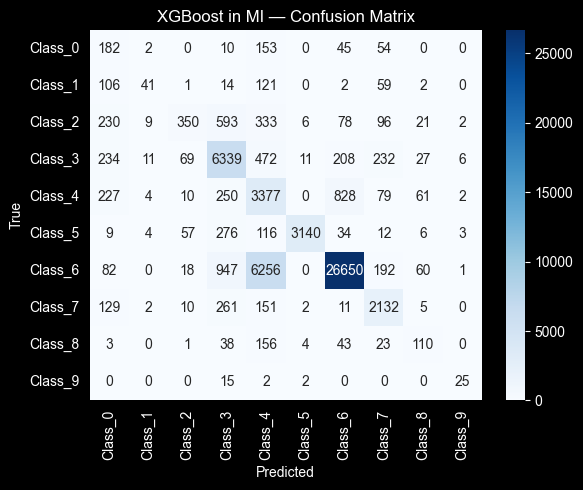

ValueError: too many values to unpack (expected 3)

In [17]:
from xgboost import XGBClassifier
model_xgboost = XGBClassifier(
    tree_method='hist',
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1,
    random_state=42
)

xgboost_mi = GridSearchCV(
    estimator=model_xgboost,
    param_grid={
        'n_estimators': [25, 50],
        'max_depth': [4, 8],
        'learning_rate': [0.15, 0.01],
    },
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
xgboost_mi.fit(
    X_train_mi,
    y_train_mi
)
print(f'Best params: {xgboost_mi.best_params_}')
y_pred_mi = xgboost_mi.predict(
    X_test_mi
)
print(f'Best params: {xgboost_mi.best_params_}')
label = f"XGBoost in MI"
acc, f1, macro = evaluate(
    label,
    y_test_mi,
    y_pred_mi
)
RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

# Wrapper models:

In [5]:
df_train_rfe_forest = pd.read_csv(r'../dataset/UNSW/wrappered/UNSW_train_rfe_forest.csv')
df_test_rfe_forest = pd.read_csv(r'../dataset/UNSW/wrappered/UNSW_test_rfe_forest.csv')

df_train_sfs_forest = pd.read_csv(r'../dataset/UNSW/wrappered/UNSW_train_sfs_forest.csv')
df_test_sfs_forest = pd.read_csv(r'../dataset/UNSW/wrappered/UNSW_test_sfs_forest.csv')

In [6]:
y_train_rfe_forest = df_train_rfe_forest['attack_cat']
X_train_rfe_forest = df_train_rfe_forest.drop(labels= 'attack_cat', axis= 1).copy()

y_test_rfe_forest = df_test_rfe_forest['attack_cat']
X_test_rfe_forest = df_test_rfe_forest.drop(labels= 'attack_cat', axis= 1).copy()

y_train_sfs_forest = df_train_rfe_forest['attack_cat']
X_train_sfs_forest = df_train_rfe_forest.drop(labels= 'attack_cat', axis= 1).copy()

y_test_sfs_forest = df_test_rfe_forest['attack_cat']
X_test_sfs_forest = df_test_rfe_forest.drop(labels= 'attack_cat', axis= 1).copy()

Best params: {'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 110}
Best params: {'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 110}

=== Random Forest on RFE Forest ===
Accuracy : 0.7529 | Precision : 0.8481 | Recall : 0.7529 | Weighted F1 : 0.7793 | Macro F1 : 0.5144
              precision    recall  f1-score   support

     Class_0       0.06      0.04      0.05       446
     Class_1       0.11      0.14      0.12       346
     Class_2       0.69      0.22      0.33      1718
     Class_3       0.71      0.87      0.78      7609
     Class_4       0.28      0.70      0.40      4838
     Class_5       0.99      0.86      0.92      3657
     Class_6       0.97      0.77      0.86     34206
     Class_7       0.89      0.78      0.83      2703
     Class_8       0.32      0.71      0.44       378
     Class_9       0.68      0.30      0.41        44

    accuracy                           0.75     55945
   macro avg       0.57      0.54      0.51     55945
weighte

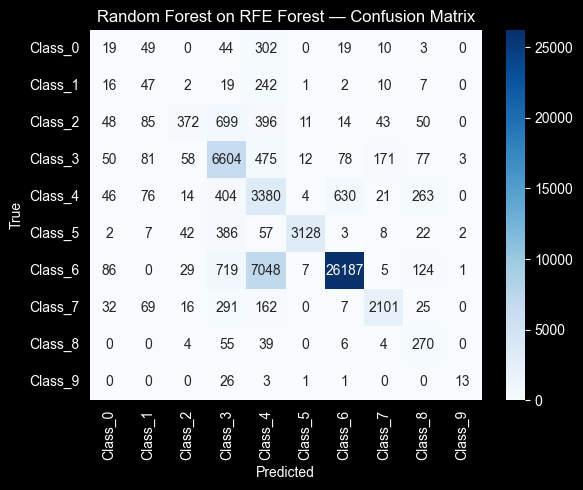

ValueError: too many values to unpack (expected 3)

In [20]:
model_rf = RandomForestClassifier(
    random_state=42
)

random_forest_rfe_forest = GridSearchCV(
    estimator=model_rf,

    param_grid={
       "n_estimators" : [100, 110],
        "criterion" : ['entropy', 'gini', 'log_loss'],
        "max_depth": [20, 15],
    },

    cv=3,

    scoring='f1_macro',

    n_jobs=-1
)

random_forest_rfe_forest.fit(
    X_train_rfe_forest,
    y_train_rfe_forest
)

print(f'Best params: {random_forest_rfe_forest.best_params_}')

y_pred_rfe_forest = random_forest_rfe_forest.predict(
    X_test_rfe_forest
)

print(f'Best params: {random_forest_rfe_forest.best_params_}')

label = f"Random Forest on RFE Forest"

acc, f1, macro = evaluate(
    label,
    y_test_rfe_forest,
    y_pred_rfe_forest
)

RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

Best params: {'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 110}
Best params: {'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 110}

=== Random Forest on SFS Forest ===
Accuracy : 0.7529 | Precision : 0.8481 | Recall : 0.7529 | Weighted F1 : 0.7793 | Macro F1 : 0.5144
              precision    recall  f1-score   support

     Class_0       0.06      0.04      0.05       446
     Class_1       0.11      0.14      0.12       346
     Class_2       0.69      0.22      0.33      1718
     Class_3       0.71      0.87      0.78      7609
     Class_4       0.28      0.70      0.40      4838
     Class_5       0.99      0.86      0.92      3657
     Class_6       0.97      0.77      0.86     34206
     Class_7       0.89      0.78      0.83      2703
     Class_8       0.32      0.71      0.44       378
     Class_9       0.68      0.30      0.41        44

    accuracy                           0.75     55945
   macro avg       0.57      0.54      0.51     55945
weighte

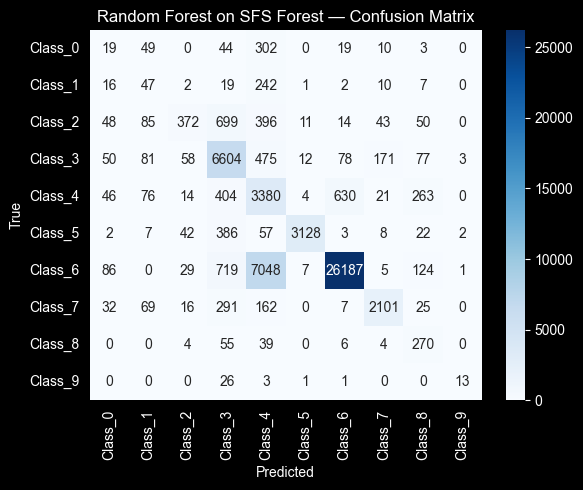

ValueError: too many values to unpack (expected 3)

In [23]:
model_rf = RandomForestClassifier(
    random_state=42
)

random_forest_sfs_forest = GridSearchCV(
    estimator=model_rf,

    param_grid={
        "n_estimators" : [100, 110],
        "criterion" : ['entropy', 'gini', 'log_loss'],
        "max_depth": [20, 15],
    },

    cv=3,

    scoring='f1_macro',

    n_jobs=-1
)

random_forest_sfs_forest.fit(
    X_train_sfs_forest,
    y_train_sfs_forest
)

print(f'Best params: {random_forest_sfs_forest.best_params_}')

y_pred_sfs_forest = random_forest_sfs_forest.predict(
    X_test_sfs_forest
)

print(f'Best params: {random_forest_sfs_forest.best_params_}')

label = f"Random Forest on SFS Forest"

acc, f1, macro = evaluate(
    label,
    y_test_sfs_forest,
    y_pred_sfs_forest
)

RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

## XGBoost:

In [9]:
df_train_rfe_xgboost = pd.read_csv(
    r'../dataset/UNSW/wrappered/UNSW_train_rfe_xgboost.csv'
)

df_test_rfe_xgboost = pd.read_csv(
    r'../dataset/UNSW/wrappered/UNSW_test_rfe_xgboost.csv'
)

df_train_sfs_xgboost = pd.read_csv(
    r'../dataset/UNSW/wrappered/UNSW_train_sfs_xgboost.csv'
)

df_test_sfs_xgboost = pd.read_csv(
    r'../dataset/UNSW/wrappered/UNSW_test_sfs_xgboost.csv'
)

In [10]:
y_train_rfe_xgboost = y_train
X_train_rfe_xgboost = df_train_rfe_xgboost.drop(
    labels='0',
    axis=1
).copy()

y_test_rfe_xgboost = y_test
X_test_rfe_xgboost = df_test_rfe_xgboost.drop(
    labels='0',
    axis=1
).copy()

y_train_sfs_xgboost = df_train_sfs_xgboost['attack_cat']
X_train_sfs_xgboost = df_train_sfs_xgboost.drop(
    labels='attack_cat',
    axis=1
).copy()

y_test_sfs_xgboost = df_test_sfs_xgboost['attack_cat']
X_test_sfs_xgboost = df_test_sfs_xgboost.drop(
    labels='attack_cat',
    axis=1
).copy()

Best params: {'learning_rate': 0.1, 'max_depth': 13, 'n_estimators': 110}
Best params: {'learning_rate': 0.1, 'max_depth': 13, 'n_estimators': 110}

=== XGBoost on RFE XGBoost ===
Accuracy : 0.7671 | Precision : 0.8486 | Recall : 0.7671 | Weighted F1 : 0.7934 | Macro F1 : 0.5799
              precision    recall  f1-score   support

     Class_0       0.12      0.29      0.17       446
     Class_1       0.11      0.30      0.16       346
     Class_2       0.66      0.30      0.41      1718
     Class_3       0.74      0.86      0.80      7609
     Class_4       0.31      0.62      0.41      4838
     Class_5       0.98      0.91      0.95      3657
     Class_6       0.97      0.78      0.86     34206
     Class_7       0.87      0.77      0.82      2703
     Class_8       0.36      0.83      0.50       378
     Class_9       0.67      0.75      0.71        44

    accuracy                           0.77     55945
   macro avg       0.58      0.64      0.58     55945
weighted avg    

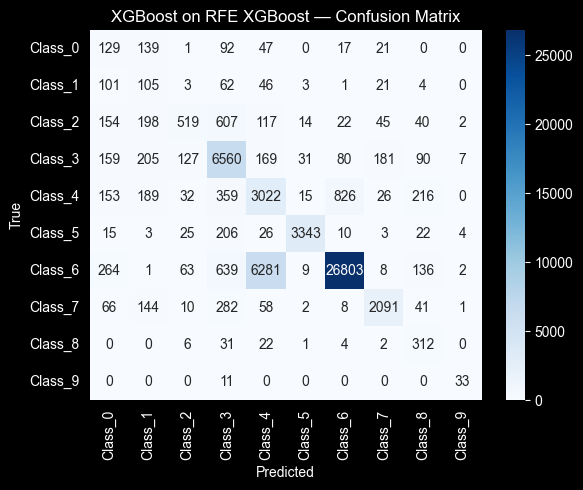

ValueError: too many values to unpack (expected 3)

In [26]:
model_xgboost = XGBClassifier(
    tree_method='hist',
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1,
    random_state=42
)

xgboost_rfe_xgboost = GridSearchCV(
    estimator=model_xgboost,

    param_grid={
        'n_estimators': [110, 115],
        'max_depth': [13, 15, 18],
        'learning_rate': [0.01, 0.1],
    },

    cv=3,

    scoring='f1_macro',

    n_jobs=-1
)

xgboost_rfe_xgboost.fit(
    X_train_rfe_xgboost,
    y_train_rfe_xgboost
)

print(f'Best params: {xgboost_rfe_xgboost.best_params_}')

y_pred_rfe_xgboost = xgboost_rfe_xgboost.predict(
    X_test_rfe_xgboost
)

print(f'Best params: {xgboost_rfe_xgboost.best_params_}')

label = f"XGBoost on RFE XGBoost"

acc, f1, macro = evaluate(
    label,
    y_test_rfe_xgboost,
    y_pred_rfe_xgboost
)

RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

Best params: {'learning_rate': 0.1, 'max_depth': 13, 'n_estimators': 115}
Best params: {'learning_rate': 0.1, 'max_depth': 13, 'n_estimators': 115}

=== XGBoost on SFS XGBoost ===
Accuracy : 0.7451 | Precision : 0.8179 | Recall : 0.7451 | Weighted F1 : 0.7660 | Macro F1 : 0.5406
              precision    recall  f1-score   support

     Class_0       0.16      0.22      0.18       446
     Class_1       0.13      0.49      0.21       346
     Class_2       0.57      0.17      0.26      1718
     Class_3       0.62      0.80      0.70      7609
     Class_4       0.32      0.64      0.43      4838
     Class_5       0.98      0.86      0.92      3657
     Class_6       0.94      0.77      0.85     34206
     Class_7       0.90      0.77      0.83      2703
     Class_8       0.38      0.46      0.41       378
     Class_9       0.61      0.61      0.61        44

    accuracy                           0.75     55945
   macro avg       0.56      0.58      0.54     55945
weighted avg    

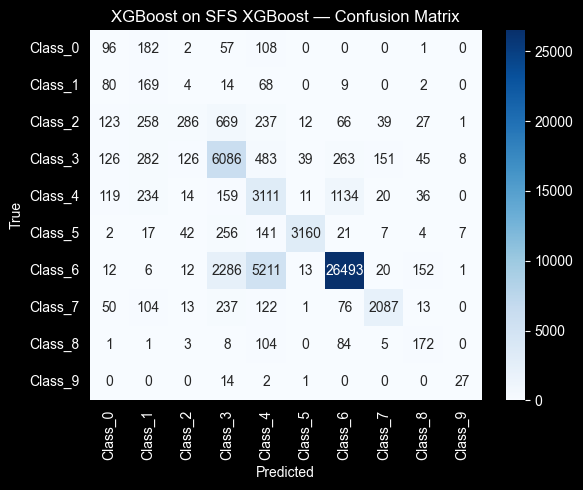

ValueError: too many values to unpack (expected 3)

In [11]:
from xgboost import XGBClassifier
model_xgboost = XGBClassifier(
    tree_method='hist',
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1,
    random_state=42
)

xgboost_sfs_xgboost = GridSearchCV(
    estimator=model_xgboost,

    param_grid={
       'n_estimators': [110, 115],
        'max_depth': [13, 15, 18],
        'learning_rate': [0.01, 0.1],
    },

    cv=3,

    scoring='f1_macro',

    n_jobs=-1
)

xgboost_sfs_xgboost.fit(
    X_train_sfs_xgboost,
    y_train_sfs_xgboost
)

print(f'Best params: {xgboost_sfs_xgboost.best_params_}')

y_pred_sfs_xgboost = xgboost_sfs_xgboost.predict(
    X_test_sfs_xgboost
)

print(f'Best params: {xgboost_sfs_xgboost.best_params_}')

label = f"XGBoost on SFS XGBoost"

acc, f1, macro = evaluate(
    label,
    y_test_sfs_xgboost,
    y_pred_sfs_xgboost
)

RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

## SVC

In [29]:
df_train_rfe_svc = pd.read_csv(
    r'../dataset/UNSW/wrappered/UNSW_train_rfe_svc.csv'
)

df_test_rfe_svc = pd.read_csv(
    r'../dataset/UNSW/wrappered/UNSW_test_rfe_svc.csv'
)

# df_train_sfs_svc = pd.read_csv(
#     r'../dataset/UNSW/wrappered/UNSW_train_sfs_svc.csv'
# )
#
# df_test_sfs_svc = pd.read_csv(
#     r'../dataset/UNSW/wrappered/UNSW_test_sfs_svc.csv'
# )

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/UNSW/wrappered/UNSW_train_sfs_svc.csv'

In [ ]:
y_train_rfe_svc = y_train
X_train_rfe_svc = df_train_rfe_svc.drop(
    labels='0',
    axis=1
).copy()

y_test_rfe_svc = y_test
X_test_rfe_svc = df_test_rfe_svc.drop(
    labels='0',
    axis=1
).copy()

# y_train_sfs_svc = df_train_sfs_svc['attack_cat']
# X_train_sfs_svc = df_train_sfs_svc.drop(
#     labels='attack_cat',
#     axis=1
# ).copy()
#
# y_test_sfs_svc = df_test_sfs_svc['attack_cat']
# X_test_sfs_svc = df_test_sfs_svc.drop(
#     labels='attack_cat',
#     axis=1
# ).copy()

Best params: {'C': 5, 'kernel': 'linear', 'tol': 0.01}
Best params: {'C': 5, 'kernel': 'linear', 'tol': 0.01}

=== SVC on RFE SVC ===
Accuracy : 0.6307   Weighted F1 : 0.6630, Macro F1: 0.3290
              precision    recall  f1-score   support

     Class_0       0.14      0.14      0.14       446
     Class_1       0.00      0.00      0.00       346
     Class_2       0.07      0.00      0.00      1718
     Class_3       0.59      0.74      0.66      7609
     Class_4       0.24      0.84      0.37      4838
     Class_5       0.97      0.82      0.89      3657
     Class_6       0.98      0.61      0.75     34206
     Class_7       0.40      0.62      0.48      2703
     Class_8       0.00      0.00      0.00       378
     Class_9       0.00      0.00      0.00        44

    accuracy                           0.63     55945
   macro avg       0.34      0.38      0.33     55945
weighted avg       0.78      0.63      0.66     55945



C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\MSI\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


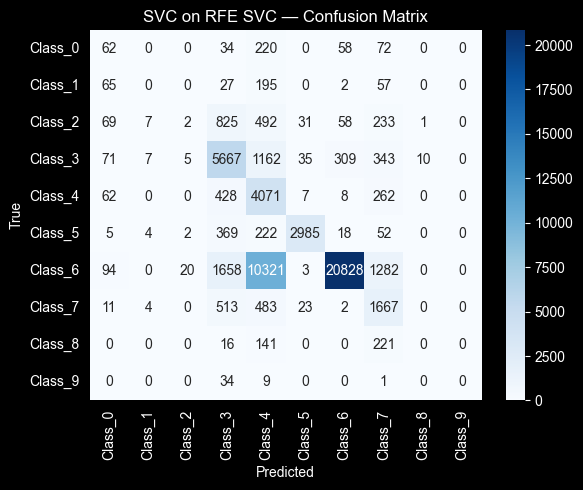

In [33]:
model_svc = SVC(
    cache_size=1000
)

svc_rfe_svc = GridSearchCV(
    estimator=model_svc,

    param_grid={
        'C': [1, 5],

        'kernel': ['linear'],

        'tol': [1e-2]
    },

    cv=3,

    scoring='f1_macro',

    n_jobs=-1
)

svc_rfe_svc.fit(
    X_train_rfe_svc,
    y_train_rfe_svc
)

print(f'Best params: {svc_rfe_svc.best_params_}')

y_pred_rfe_svc = svc_rfe_svc.predict(
    X_test_rfe_svc
)

print(f'Best params: {svc_rfe_svc.best_params_}')

label = f"SVC on RFE SVC"

acc, f1, macro = evaluate(
    label,
    y_test_rfe_svc,
    y_pred_rfe_svc
)

RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}

In [ ]:
model_svc = SVC(
    cache_size=1000
)

svc_sfs_svc = GridSearchCV(
    estimator=model_svc,

    param_grid={
        'C': [5, 10],

        'kernel': ['linear'],

        'tol': [1e-1]
    },

    cv=2,

    scoring='f1_macro',

    n_jobs=-1
)

svc_sfs_svc.fit(
    X_train_sfs_svc,
    y_train_sfs_svc
)

print(f'Best params: {svc_sfs_svc.best_params_}')

y_pred_sfs_svc = svc_sfs_svc.predict(
    X_test_sfs_svc
)

print(f'Best params: {svc_sfs_svc.best_params_}')

label = f"SVC on SFS SVC"

acc, f1, macro = evaluate(
    label,
    y_test_sfs_svc,
    y_pred_sfs_svc
)

RESULTS[label] = {
    'Accuracy': acc,
    'F1': f1,
    'Macro F1': macro
}